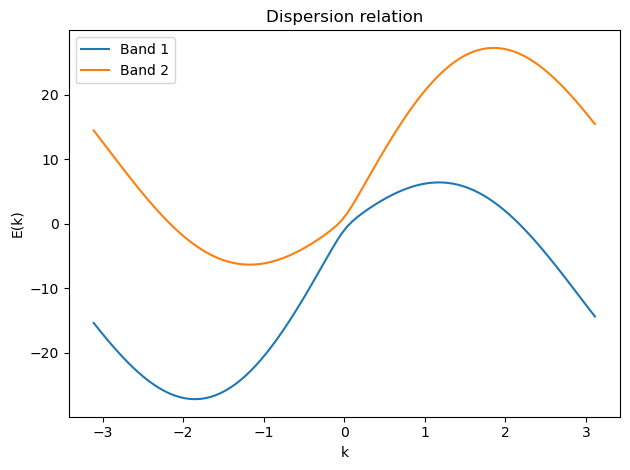

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

# --- parameters ---
l = 2*np.pi
L = 100
epsilon = l / L

n = np.linspace(-(L/2)+1, (L/2), L)
k = (2*np.pi/L)*(n - 0.5)
alpha = 1
beta = 2
gamma = 1
p = 1

zeta = np.pi/2
m = 2

# --- matrix elements (length-L arrays) ---
A = (-1/(2*epsilon))*(p*np.cos(k) - beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))
B = (-1/(2*epsilon))*(alpha/gamma)*(np.cos(zeta) - 1j*np.sin(zeta))*1j*np.sin(k)
C = (-1/(2*epsilon))*-1*(alpha/gamma)*(np.cos(zeta) + 1j*np.sin(zeta))*1j*np.sin(k)
D = -1*(-1/(2*epsilon))*(p*np.cos(k) + beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))

# --- stack as (L,2,2): each slice is H(k_i) ---
Hk = np.array([[A, B],
               [C, D]])            # shape (2,2,L)
Hk = np.transpose(Hk, (2,0,1))      # shape (L,2,2)

# --- eigenvalues (dispersion) for each k ---
#   Hermitian が保証できない場合に備え eig を用い、描画には実部を使用
evals, evecs = LA.eig(Hk)           # evals shape: (L,2)

# 連続性をよくするため、各 k で昇順にソート
E_sorted = np.sort(evals.real, axis=1)   # (L,2)

# --- plot dispersion E(k) ---
plt.figure()
plt.plot(k, E_sorted[:,0], label='Band 1')
plt.plot(k, E_sorted[:,1], label='Band 2')
plt.xlabel('k')
plt.ylabel('E(k)')
plt.title('Dispersion relation')
plt.legend()
plt.tight_layout()
plt.show()


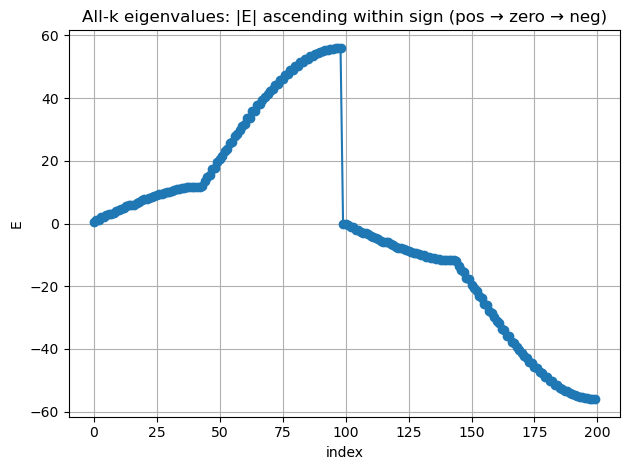

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

# =========================
# パラメータ設定
# =========================
l = 2*np.pi
L = 100
epsilon = l / L

n = np.linspace(-(L/2) + 1, (L/2), L)
k = (2*np.pi/L) * (n)
alpha = 1
beta = -2
gamma = 1
p = 1

zeta = np.pi/2
m = 0

# =========================
# 行列要素（長さ L の配列）
# =========================
A = (-1/(epsilon)) * (p*np.cos(k) - beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))
B = (-1/(epsilon)) * (alpha/gamma) * (np.cos(zeta) - 1j*np.sin(zeta)) * 1j*np.sin(k)
C = (-1/(epsilon)) * (-1) * (alpha/gamma) * (np.cos(zeta) + 1j*np.sin(zeta)) * 1j*np.sin(k)
D = -1 * (-1/(epsilon)) * (p*np.cos(k) + beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))

# =========================
# H(k) を (L, 2, 2) に整形
# =========================
Hk = np.array([[A, B],
               [C, D]])            # 形状 (2, 2, L)
Hk = np.transpose(Hk, (2, 0, 1))    # 形状 (L, 2, 2) — 各スライスが 2x2 行列

# =========================
# 固有値（全 k について）
# =========================
eigvals = LA.eigvals(Hk).real       # 形状 (L, 2) → 実部のみ採用
vals = eigvals.flatten()            # 2L 個の一次元配列

# =========================
# 正・ゼロ・負に分割（数値誤差対策 tol）
# =========================
tol = 1e-12
pos = vals[vals >  tol]
zer = vals[np.abs(vals) <= tol]
neg = vals[vals < -tol]

# それぞれ絶対値の昇順でソート
pos_sorted = pos[np.argsort(np.abs(pos))]
zer_sorted = np.sort(zer)  # 0 なので任意だが、念のため昇順
neg_sorted = neg[np.argsort(np.abs(neg))]

# =========================
# 連結（正 → 0 → 負）
# =========================
final_vals = np.concatenate([pos_sorted, zer_sorted, neg_sorted])

# =========================
# プロット
# =========================
plt.figure()
plt.plot(final_vals, marker='o')
plt.xlabel('index')
plt.ylabel('E')
plt.title('All-k eigenvalues: |E| ascending within sign (pos → zero → neg)')
plt.tight_layout()
plt.grid()
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

In [10]:
l = 2*np.pi
L = 1000
epsilon = l / L

n = np.linspace(-(L/2)+1,(L/2),L)
k = (2*np.pi/L)*(n-0.5)
alpha = np.sqrt((4*np.pi/(2*np.pi))*np.exp(-np.pi/(2*np.pi)))
beta = -2
gamma = np.sqrt((4*np.pi/(2*np.pi))*np.exp(-np.pi/(2*np.pi)))
p = 1

zeta = np.pi/2
m = 0

In [11]:
A = (-1/(2*epsilon))*(p*np.cos(k) - beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))
B = (-1/(2*epsilon))*(alpha/gamma)*(np.cos(zeta) - 1j*np.sin(zeta))*1j*np.sin(k)
C = (-1/(2*epsilon))*-1*(alpha/gamma)*(np.cos(zeta) + 1j*np.sin(zeta))*1j*np.sin(k)
D = -1*(-1/(2*epsilon))*(p*np.cos(k) + beta*np.sin(k) - 0.5*(2*p - epsilon*(2*m*alpha)))

In [12]:
E1 = (A+D)/2 + np.sqrt(((A+D)/2)**2 + B*C - A*D)
E2 = (A+D)/2 - np.sqrt(((A+D)/2)**2 + B*C - A*D)

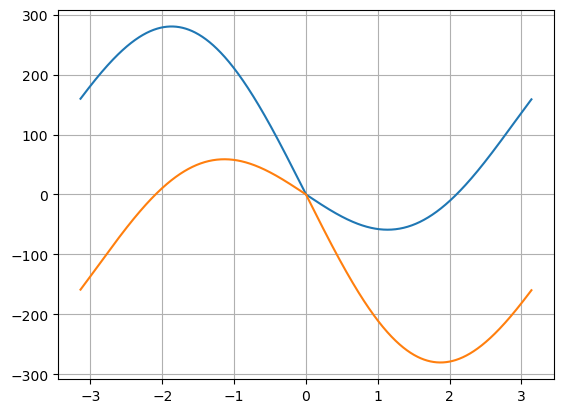

In [13]:
plt.plot(k,E1)
plt.plot(k,E2)
plt.grid()
plt.show()

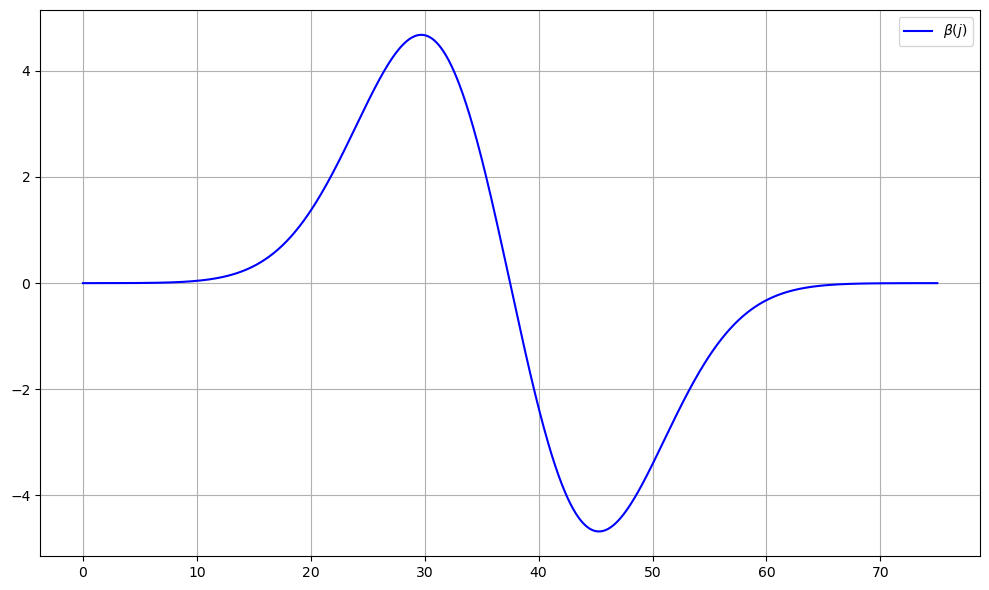

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
l = 4*np.pi
L = 300
epsilon = l/L

# 関数定義
def beta(j):
    x = epsilon * j - np.pi /2
    return -1 * np.exp(np.pi**2 / 4 - (2 * x)**2) * np.sin(2 * x)

# プロット範囲
j_vals = np.linspace(0, np.pi / epsilon, 1000)
beta_vals = beta(j_vals)

# グラフの描画
plt.figure(figsize=(10, 6))
plt.plot(j_vals, beta_vals, label=r"$\beta(j)$", color='blue')

# 軸ラベルとタイトル
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
l = np.pi
L = 1000
epsilon = l/L
def beta(j):
    x = epsilon*j - np.pi/2
    return -1/4*np.exp(np.pi**2/4-(2*x)**2)*np.sin(2*x)
print(beta(566))

-1.0000878424898365


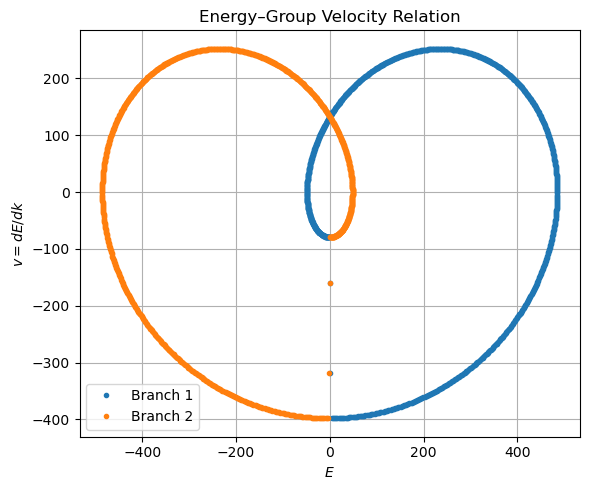

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA
from scipy.interpolate import interp1d

# -----------------------------
# 1. パラメータ設定
# -----------------------------
l       = np.pi
L       = 1000
epsilon = l / L
n       = np.linspace(-L/2+1, L/2, L)
k       = (2 * np.pi / L) * (n - 0.5)

alpha = 1.0
beta  = -1.5
gamma = 1.0
p     = 1
m     = 0
zeta  = np.pi / 2

# -----------------------------
# 2. 行列要素 A, B, C, D の定義
# -----------------------------
A = (-1/(2*epsilon)) * ( p*np.cos(k) 
                         - beta*np.sin(k) 
                         - 0.5*(2*p - epsilon*(2*m*alpha)) )
B = (-1/(2*epsilon)) * (alpha/gamma) * (np.cos(zeta) - 1j*np.sin(zeta)) * 1j*np.sin(k)
C = (-1/(2*epsilon)) * -1 * (alpha/gamma) * (np.cos(zeta) + 1j*np.sin(zeta)) * 1j*np.sin(k)
D = -1 * (-1/(2*epsilon)) * ( p*np.cos(k) 
                             + beta*np.sin(k) 
                             - 0.5*(2*p - epsilon*(2*m*alpha)) )

# -----------------------------
# 3. 分散関係 E1, E2 の計算
# -----------------------------
disc = np.sqrt(((A+D)/2)**2 + B*C - A*D)
E1 = (A + D)/2 + disc
E2 = (A + D)/2 - disc

# -----------------------------
# 4. 群速度 v1=dE1/dk, v2=dE2/dk の数値微分
# -----------------------------
v1 = np.gradient(E1, k)
v2 = np.gradient(E2, k)

# -----------------------------
# 5. E–v 関係のプロット
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(E1.real, v1.real, '.', label='Branch 1')
plt.plot(E2.real, v2.real, '.', label='Branch 2')
plt.xlabel(r'$E$')
plt.ylabel(r'$v = dE/dk$')
plt.title('Energy–Group Velocity Relation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. （任意）補間関数の生成例
# -----------------------------
# E の値から v を取得したい場合は次のように interp1d を使います
# f1 = interp1d(E1.real, v1.real, kind='cubic', assume_sorted=False)
# E_query = 0.5
# v1_at_0_5 = f1(E_query)
# print(f"Branch1: E={E_query} -> v≈{v1_at_0_5:.3f}")


In [10]:
#https://github.com/bshoshany/ OGRePy使用したライブラリ
import OGRePy as T #一般相対論計算用ライブラリのインポート
from OGRePy.abc import t, theta, phi, M #シュワルツシルト計量の線素に使われるシンボルの作成
from OGRePy.abc import rho, sigma, mu, nu #テンソルのインデックスに使われるシンボルの作成

r = T.sym("r", nonnegative=True) #rは非負として扱うために別で作成

Spherical = T.Coordinates(t, r, theta, phi)#球座標を指定

Schwarzschild = T.Metric(
    coords=Spherical, #座標指定
    components=T.diag( #計量テンソル指定
        -(1 - 2 * M / r),
        1 / (1 - 2 * M / r),
        r**2,
        r**2 * T.s.sin(theta) ** 2,
    ),
)

Schwarzschild.riemann(rho, sigma, mu, nu) @ Schwarzschild.riemann(rho, sigma, mu, nu) #計算

$$R{}_{\mu}{}_{\nu}{}_{\rho}{}_{\sigma} R{}^{\mu}{}^{\nu}{}^{\rho}{}^{\sigma}\Bigg|_{\left(t, r, \theta, \phi\right)} = \frac{48 M^{2}}{r^{6}}$$

In [18]:
import sympy as sp

t, r, theta, phi, M = sp.symbols('t r theta phi M')#パラメータのシンボル作成
coords = (t, r, theta, phi)#座標指定

#計量テンソルの定義
g = sp.diag(
    -(1 - 2*M/r),
    1/(1 - 2*M/r),
    r**2,
    r**2 * sp.sin(theta)**2
)

#計量の逆行列作成
g_inv = g.inv()

#Christoffel記号
Gamma = {}
for i in range(4):
    for j in range(4):
        for k in range(4):
            term = 0
            for l in range(4):
                term += g_inv[i, l] * 1/2 *(
                    g[j, l].diff(coords[k]) +
                    g[k, l].diff(coords[j]) -
                    g[j, k].diff(coords[l])
                )
            Gamma[(i, j, k)] = sp.simplify(term)

#Ricciテンソル
R = {}
for i in range(4):
    for j in range(4):
        term = 0
        for k in range(4):
            term += Gamma[(k, i, j)].diff(coords[k]) - Gamma[(k, i, k)].diff(coords[j])
            for l in range(4):
                term += Gamma[(k, i, j)] * Gamma[(l, k, l)] - Gamma[(k, i, l)] * Gamma[(l, k, j)]
        R[(i, j)] = sp.simplify(term)

#スカラー曲率
scalar_R = sum(g_inv[i, j] * R[(i, j)] for i in range(4) for j in range(4))
scalar_R = sp.simplify(scalar_R)

#アインシュタインテンソル
G = {}
for i in range(4):
    for j in range(4):
        G[(i, j)] = sp.simplify(R[(i, j)] - sp.Rational(1, 2) * g[i, j] * scalar_R)

print(G)

{(0, 0): 0, (0, 1): 0, (0, 2): 0, (0, 3): 0, (1, 0): 0, (1, 1): 0, (1, 2): 0, (1, 3): 0, (2, 0): 0, (2, 1): 0, (2, 2): 0, (2, 3): 0, (3, 0): 0, (3, 1): 0, (3, 2): 0, (3, 3): 0}


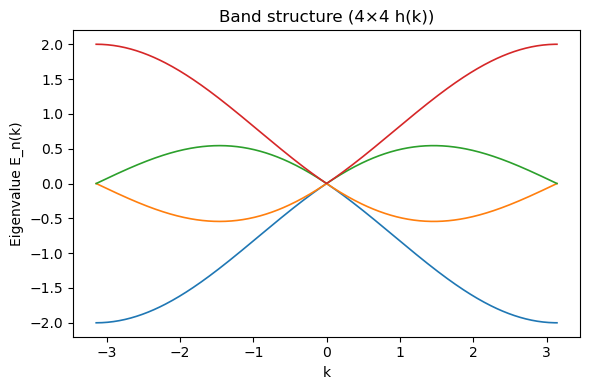

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1) ここを編集: h(k) を定義する
#    例として 4×4 の Hermitian 行列を置いています。
#    実際のモデルに合わせて書き換えてください。
# ===============================
l = np.pi
L = 300
epsilon = l / L

def is_hermitian(matrix: np.ndarray, tol: float = 1e-5) -> bool:
    """
    与えられた行列がエルミート (Hermitian) か判定する関数

    Parameters
    ----------
    matrix : np.ndarray
        対象となる行列（2次元配列）
    tol : float, optional
        数値誤差を許容する閾値（デフォルトは1e-10）

    Returns
    -------
    bool
        True なら Hermitian, False なら非 Hermitian
    """
    return np.allclose(matrix, matrix.conj().T, atol=tol)

def h_of_k(k: float) -> np.ndarray:
    # 例: 二つの 2×2 ブロック（パウリ行列に相当する形）
    p = 0
    m = 0
    beta = -1
    block1 = np.array([[ -(p - epsilon*m)/2, (p*(1 + np.exp(-1j*k)) + 1j*beta*(1 - np.exp(-1j*k)))/2],
                       [ (p*(1 + np.exp(1j*k)) - 1j*beta*(1 - np.exp(1j*k)))/2,-(p - epsilon*m)/2]])
    block2 = np.array([[ (p - epsilon*m)/2, -1*(p*(1 + np.exp(1j*k)) - 1j*beta*(1 - np.exp(1j*k)))/2],
                       [ -1*(p*(1 + np.exp(-1j*k)) + 1j*beta*(1 - np.exp(-1j*k)))/2,(p - epsilon*m)/2]])
    block3 = np.array([[ 0, (-np.exp(-1j*k) + 1)/2],
                       [ (np.exp(1j*k) - 1)/2,0]])
    block4 = np.array([[ 0, (np.exp(-1j*k) - 1)/2],
                       [ (-np.exp(1j*k) + 1)/2,0]])
    # ブロック対角に結合して 4×4 を作る
    H = np.block([
        [block1,         block3],
        [block4, block2       ]
    ])
    return H  # Hermitian

# ===============================
# 2) k グリッドの設定（必要に応じて変更）
# ===============================
Nk = 400                       # k 分割数
kmin, kmax = -np.pi, np.pi     # 例: 1 次元 BZ [-π, π]
ks = np.linspace(kmin, kmax, Nk)

# ===============================
# 3) 各 k で固有値のみを計算
#    Hermitian なら eigvalsh（推奨）
#    非 Hermitian の場合は eigvals に変更
# ===============================
eigvals = np.empty((Nk, 4), dtype=float)
for i, k in enumerate(ks):
    if not is_hermitian(h_of_k(k)):
        print("no")
    w = np.linalg.eigvalsh(h_of_k(k))  # 実数が返る
    w.sort()                           # 昇順ソートでバンド整列
    eigvals[i] = w

# ===============================
# 4) プロット（バンド図）
#    注意: 本環境の規約により matplotlib を使用し、
#          色やスタイルは指定しません。
# ===============================
plt.figure(figsize=(6,4))
for band in range(4):
    plt.plot(ks, eigvals[:, band], linewidth=1.2)
plt.xlabel("k")
plt.ylabel("Eigenvalue E_n(k)")
plt.title("Band structure (4×4 h(k))")
plt.tight_layout()
plt.show()

# ===============================
# 5) データ保存（任意）
# ===============================
# np.savetxt("bands.csv", np.column_stack([ks, eigvals]), delimiter=",",
#            header="k,E1,E2,E3,E4", comments="")

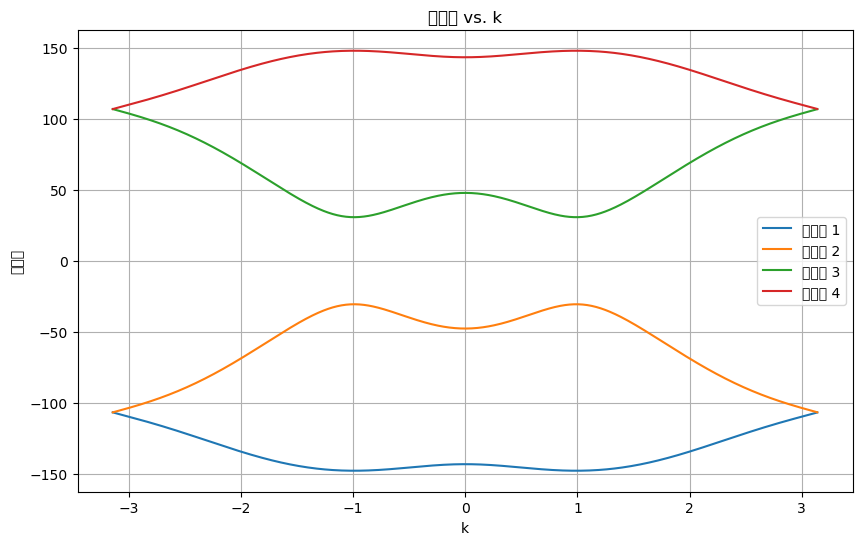

In [15]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

p = 1
beta = 0
l = np.pi
L = 300
epsilon = l/L
m = 0

def h_k(k):
    h = np.array([[-(p-epsilon*m)/2, (p*(1+np.exp(-1j*k))+1j*beta*(1-np.exp(-1j*k)))/2, 0, -(np.exp(1j*k)-1)/2],
                 [np.conj((p*(1+np.exp(-1j*k))+1j*beta*(1-np.exp(-1j*k)))/2), -(p-epsilon*m)/2, (np.exp(1j*k)-1)/2, 0],
                 [0, np.conj((np.exp(1j*k)-1)/2), (p-epsilon*m)/2, np.conj(-(p*(1+np.exp(1j*k))+1j*beta*(1-np.exp(1j*k)))/2)],
                 [np.conj(-(np.exp(1j*k)-1)/2), 0, -(p*(1+np.exp(1j*k))+1j*beta*(1-np.exp(1j*k)))/2, (p-epsilon*m)/2]])
    return -1/epsilon*h

# プロット用のデータ準備
k_values = np.arange(-np.pi, np.pi, 0.01)
eigenvalue_lists = [[] for _ in range(4)]

for k in k_values:
    # 固有値を計算 (LA.eighは自動的にソートします)
    values, _ = LA.eigh(h_k(k))
    for i in range(4):
        eigenvalue_lists[i].append(values[i])

# 固有値のプロット
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(k_values, eigenvalue_lists[i], label=f'固有値 {i+1}')

plt.title('固有値 vs. k')
plt.xlabel('k')
plt.ylabel('固有値')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

p = 1
beta = 0
l = np.pi
L = 300
epsilon = l/L
m = 0

def h_k(k):
    h = np.array([[-(p-epsilon*m)/2, (p*(2*np.cos(k))+1j*beta*(2*1j*np.sin(k))/2, 0, -(np.exp(1j*k)-1)/2],
                 [np.conj((p*(1+np.exp(-1j*k))+1j*beta*(1-np.exp(-1j*k)))/2), -(p-epsilon*m)/2, (np.exp(1j*k)-1)/2, 0],
                 [0, np.conj((np.exp(1j*k)-1)/2), (p-epsilon*m)/2, np.conj(-(p*(1+np.exp(1j*k))+1j*beta*(1-np.exp(1j*k)))/2)],
                 [np.conj(-(np.exp(1j*k)-1)/2), 0, -(p*(1+np.exp(1j*k))+1j*beta*(1-np.exp(1j*k)))/2, (p-epsilon*m)/2]])
    return -1/epsilon*h

# プロット用のデータ準備
k_values = np.arange(-np.pi, np.pi, 0.01)
eigenvalue_lists = [[] for _ in range(4)]

for k in k_values:
    # 固有値を計算 (LA.eighは自動的にソートします)
    values, _ = LA.eigh(h_k(k))
    for i in range(4):
        eigenvalue_lists[i].append(values[i])

# 固有値のプロット
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(k_values, eigenvalue_lists[i], label=f'固有値 {i+1}')

plt.title('固有値 vs. k')
plt.xlabel('k')
plt.ylabel('固有値')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

p = 1
beta = 0
l = np.pi
L = 300
epsilon = l/L
m = 0

for k in np.arange(-np.pi/2, np.pi, 0.01):
    h00 = -(p-epsilon*m)
    h01 = p*np.cos(k) - beta*np.sin(k)
    h32 = -(p*np.cos(k) + beta*np.sin(k))
    h03 = 1j*np.sin(k)
    h12 = 1j*np.sin(k)
    
    h = np.arrray([[h00, h01, 0, h03],
                  [np.conj(h01), h00, h12, 0],
                  [0, np.conj(h12), -h00, np.conj(h32)],
                  [np.conj(h03), 0, h32, -h00]])
    vals, _ = LA.eigh(h)

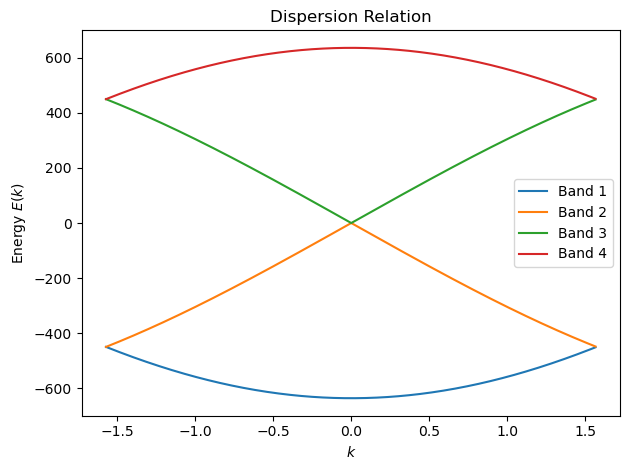

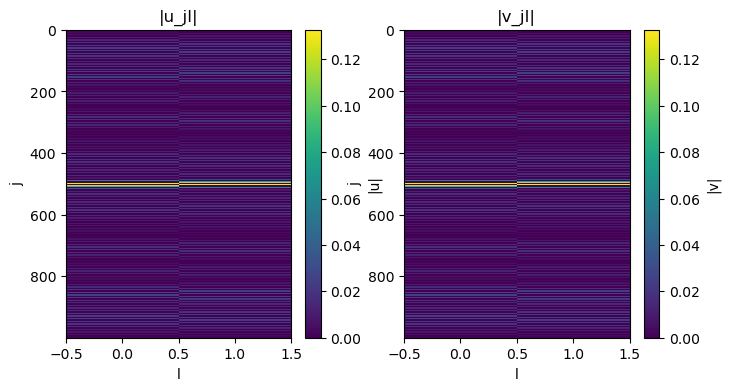

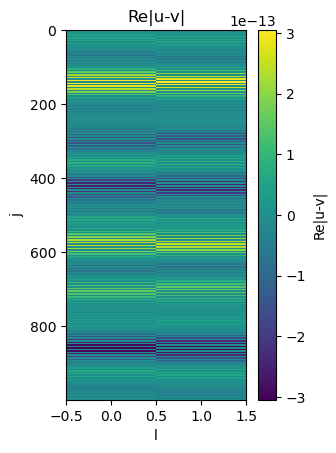

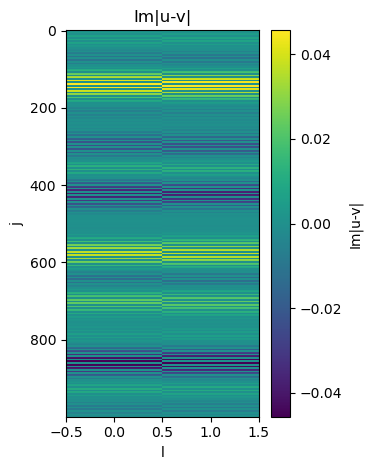

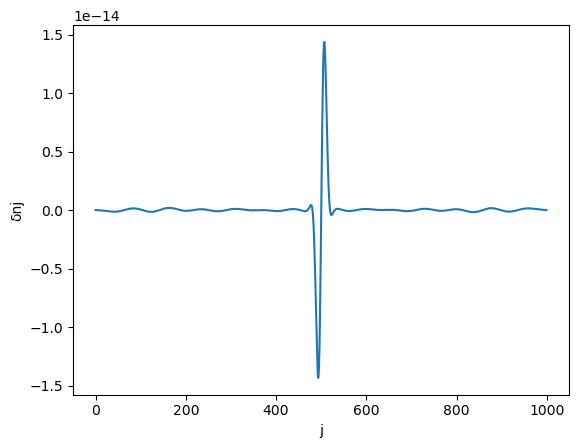

In [28]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

p = 1
beta = 0
l = np.pi
L = 1000
epsilon = l/L
m = 0
vecs_list = []
k_vals = np.arange(-np.pi/2, np.pi/2, 2*np.pi/L)
bands = np.zeros((len(k_vals), 4), dtype=float)

for idx, k in enumerate(k_vals):
    h00 = -(p - epsilon*m)
    h01 = p*np.cos(k) - beta*np.sin(k)
    h32 = -(p*np.cos(k) + beta*np.sin(k))
    h03 = 1j*np.sin(k)
    h12 = 1j*np.sin(k)

    h = np.array([
        [h00,           h01,           0,            h03],
        [np.conj(h01),  h00,           h12,          0  ],
        [0,             np.conj(h12),  -h00,         np.conj(h32)],
        [np.conj(h03),  0,             h32,          -h00]
    ], dtype=complex)

    vals, vecs = LA.eigh(h*(-1/epsilon))
    bands[idx, :] = vals
    vecs_list.append(vecs.conj().T)
'''
    # --- 対角化の確認 ---
    D = vecs.conj().T @ (h*(-1/epsilon)) @ vecs
    print("k =", k)
    print(np.round(D, 6))   # 数値誤差を丸めて表示
    print("固有値 =", vals)
    print()

for vecs in vecs_list:
    # --- ユニタリの確認 ---
    D = vecs.conj().T @ vecs
    print(np.round(D, 6))   # 数値誤差を丸めて表示
''' 

# 分散関係の描画
plt.figure()
for n in range(bands.shape[1]):
    plt.plot(k_vals, bands[:, n], label=f'Band {n+1}')

plt.xlabel(r'$k$')
plt.ylabel(r'Energy $E(k)$')
plt.title('Dispersion Relation')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

particles = np.zeros(L, dtype=complex)
u = np.zeros((L,2), dtype=complex)
v = np.zeros((L,2), dtype=complex)
k0 = 0
x0 = int(L/2)
band_num = 1
dk = 0.1

weights = np.exp(-(k_vals - k0)**2 / (2*dk**2)) * np.exp(-1j*k_vals*x0)
A = 1 / np.sqrt(np.sum(np.abs(weights)**2))

for j in range(int(L)):
    for i, k in enumerate(k_vals):
        coeff = (1/np.sqrt(L/2)) * A * weights[i]
        if j%2 == 0:
            u[j,0] += coeff * vecs_list[i][band_num, 0].conj() * np.exp(1j*k*j)
            v[j,0] += coeff * vecs_list[i][band_num, 0].conj() * np.exp(-1j*k*j)
        else:
            u[j,1] += coeff * vecs_list[i][band_num, 1].conj() * np.exp(1j*k*j)
            v[j,1] += coeff * vecs_list[i][band_num, 1].conj() * np.exp(-1j*k*j)

dn_list = []
for j in range(int(L)):
    dn_list.append(np.abs(u[j,0])**2 - np.abs(v[j,0])**2)
    dn_list[-1] += np.abs(u[j,1])**2 - np.abs(v[j,1])**2

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(np.abs(u), cmap="viridis", aspect="auto", interpolation="none")
plt.colorbar(label="|u|")
plt.xlabel("l")
plt.ylabel("j")
plt.title("|u_jl|")

plt.subplot(1,2,2)
plt.imshow(np.abs(v), cmap="viridis", aspect="auto", interpolation="none")
plt.colorbar(label="|v|")
plt.xlabel("l")
plt.ylabel("j")
plt.title("|v_jl|")

plt.show()

plt.subplot(1,2,2)
plt.imshow((u - v).real, cmap="viridis", aspect="auto", interpolation="none")
plt.colorbar(label="Re|u-v|")
plt.xlabel("l")
plt.ylabel("j")
plt.title("Re|u-v|")

plt.show()

plt.subplot(1,2,2)
plt.imshow((u - v).imag, cmap="viridis", aspect="auto", interpolation="none")
plt.colorbar(label="Im|u-v|")
plt.xlabel("l")
plt.ylabel("j")
plt.title("Im|u-v|")

plt.tight_layout()
plt.show()


plt.plot(dn_list)
plt.xlabel("j")
plt.ylabel("δnj")
plt.show()

In [16]:
for i in range(1,3):
    print(i)

1
2
